In [1]:
import os
import shutil
from google.colab import drive

# --- 1. Mount Drive ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# --- 2. Paths ---
PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
LOCAL_DATA = '/content/data'

# unzip locally
need_unzip = not (
    os.path.exists(os.path.join(LOCAL_DATA, 'PlantVillage')) and
    len(os.listdir(os.path.join(LOCAL_DATA, 'PlantVillage'))) > 30
)

if need_unzip:
    print("Re-unzipping data to local SSD...")
    for f in ['PlantVillage', 'PlantDoc']:
        path = os.path.join(LOCAL_DATA, f)
        if os.path.exists(path):
            shutil.rmtree(path)
    os.makedirs(os.path.join(LOCAL_DATA, 'PlantVillage'), exist_ok=True)
    os.makedirs(os.path.join(LOCAL_DATA, 'PlantDoc'), exist_ok=True)

    !unzip -q "$PROJECT_DRIVE/plantvillage-dataset.zip" -d "$LOCAL_DATA/PlantVillage"
    !unzip -q "$PROJECT_DRIVE/PlantDoc-Dataset-master.zip" -d "$LOCAL_DATA/PlantDoc"

    # Flatten PlantVillage
    pv_nested = os.path.join(LOCAL_DATA, 'PlantVillage', 'plantvillage dataset')
    if os.path.exists(pv_nested):
        color_path = os.path.join(pv_nested, 'color')
        source = color_path if os.path.exists(color_path) else pv_nested
        for item in os.listdir(source):
            shutil.move(os.path.join(source, item), os.path.join(LOCAL_DIR := LOCAL_DATA, 'PlantVillage', item))

    # Flatten PlantDoc
    pd_nested = os.path.join(LOCAL_DATA, 'PlantDoc', 'PlantDoc-Dataset-master')
    if os.path.exists(pd_nested):
        for item in os.listdir(pd_nested):
            shutil.move(os.path.join(pd_nested, item), os.path.join(LOCAL_DATA, 'PlantDoc', item))
    print("Done unzipping!")
else:
    print("✅ Data already present locally.")

# --- 4. Verify split CSVs exist on Drive ---
split_dir = os.path.join(PROJECT_DRIVE, 'results', 'splits')
print(f"\nSplits on Drive: {os.listdir(split_dir)}")

# --- 5. Verify model/results folders exist ---
for sub in ['metrics', 'figures', 'models']:
    path = os.path.join(PROJECT_DRIVE, 'results', sub)
    os.makedirs(path, exist_ok=True)

print(f"\n✅ PlantVillage classes: {len(os.listdir(os.path.join(LOCAL_DATA, 'PlantVillage')))}")
print(f"✅ PlantDoc classes:     {len(os.listdir(os.path.join(LOCAL_DATA, 'PlantDoc', 'train')))}")

Mounted at /content/drive
Re-unzipping data to local SSD...
Done unzipping!

Splits on Drive: ['class_names.csv', 'train.csv', 'val.csv', 'test.csv']

✅ PlantVillage classes: 39
✅ PlantDoc classes:     28


In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
SPLIT_DIR = os.path.join(PROJECT_DRIVE, 'results', 'splits')

IMG_SIZE = 224
BATCH_SIZE = 32

def load_split_from_drive():
    train_df = pd.read_csv(os.path.join(SPLIT_DIR, 'train.csv'))
    val_df   = pd.read_csv(os.path.join(SPLIT_DIR, 'val.csv'))
    test_df  = pd.read_csv(os.path.join(SPLIT_DIR, 'test.csv'))
    class_df = pd.read_csv(os.path.join(SPLIT_DIR, 'class_names.csv'))
    class_to_idx = dict(zip(class_df['class'], class_df['index']))
    return train_df, val_df, test_df, class_to_idx

def decode_img(filepath, label, num_classes):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, num_classes)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.12)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, class_to_idx, num_classes, training=False):
    paths = df['filepath'].values
    labels = np.array([class_to_idx[l] for l in df['label'].values], dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = ds.map(lambda p, l: decode_img(p, l, num_classes),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def get_all_datasets():
    train_df, val_df, test_df, class_to_idx = load_split_from_drive()
    num_classes = len(class_to_idx)
    train_ds = make_dataset(train_df, class_to_idx, num_classes, training=True)
    val_ds   = make_dataset(val_df,   class_to_idx, num_classes, training=False)
    test_ds  = make_dataset(test_df,  class_to_idx, num_classes, training=False)
    return train_ds, val_ds, test_ds, class_to_idx

# Load them now so subsequent cells can use them
train_ds, val_ds, test_ds, class_to_idx = get_all_datasets()
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
NUM_CLASSES = len(class_to_idx)

print(f"✅ Train batches: {len(train_ds)}")
print(f"✅ Val batches:   {len(val_ds)}")
print(f"✅ Test batches:  {len(test_ds)}")
print(f"✅ Classes:       {NUM_CLASSES}")

✅ Train batches: 1358
✅ Val batches:   170
✅ Test batches:  170
✅ Classes:       38


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

📋 EFFICIENTNETB0
   Total params:     4,387,273
   Trainable params: 337,702 (head only — backbone frozen)

🚀 Training EFFICIENTNETB0...

Epoch 1/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7744 - loss: 0.8237
Epoch 1: val_accuracy improved from None to 0.94991, saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/efficientnetb0.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 138s 82ms/step - accuracy: 0.8641 - loss: 0.4548 - val_accuracy: 0.9499 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 2/12
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9238 - loss: 0.2286
Epoch 2: val_accuracy improved from 0.94991 to 0.96446, saving model to /content/drive/MyDrive/PlantDiseaseProject/results/models/efficientnetb0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PlantDiseasePro

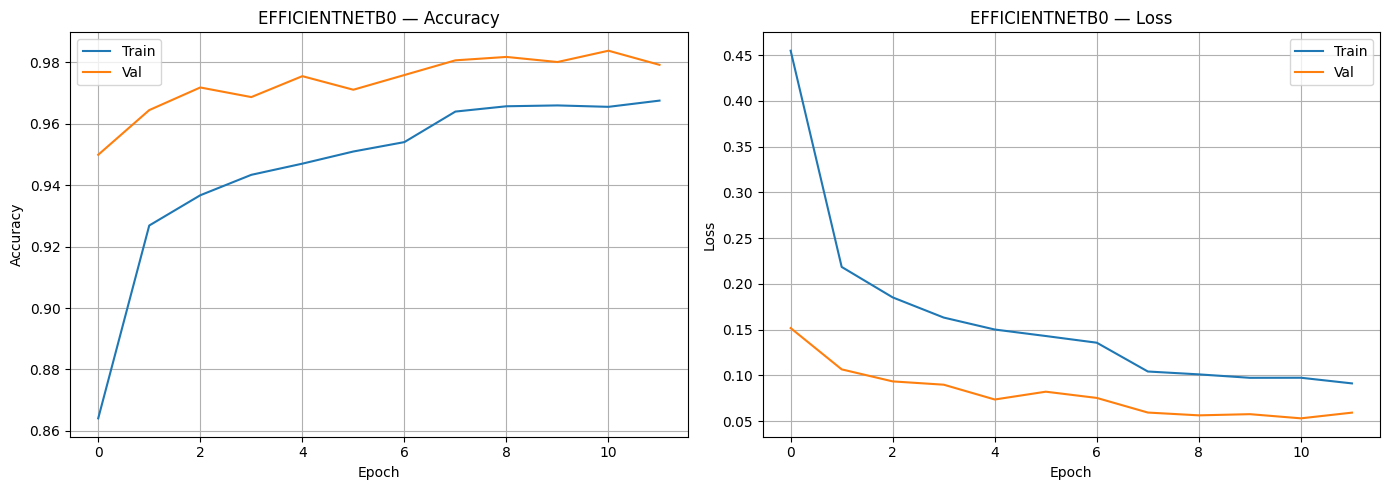


📊 Evaluating on test set...
170/170 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step

🎯 TEST Accuracy: 98.36%
🎯 Macro F1:      0.9785
⏱️ Inference:     4.55 ms/image


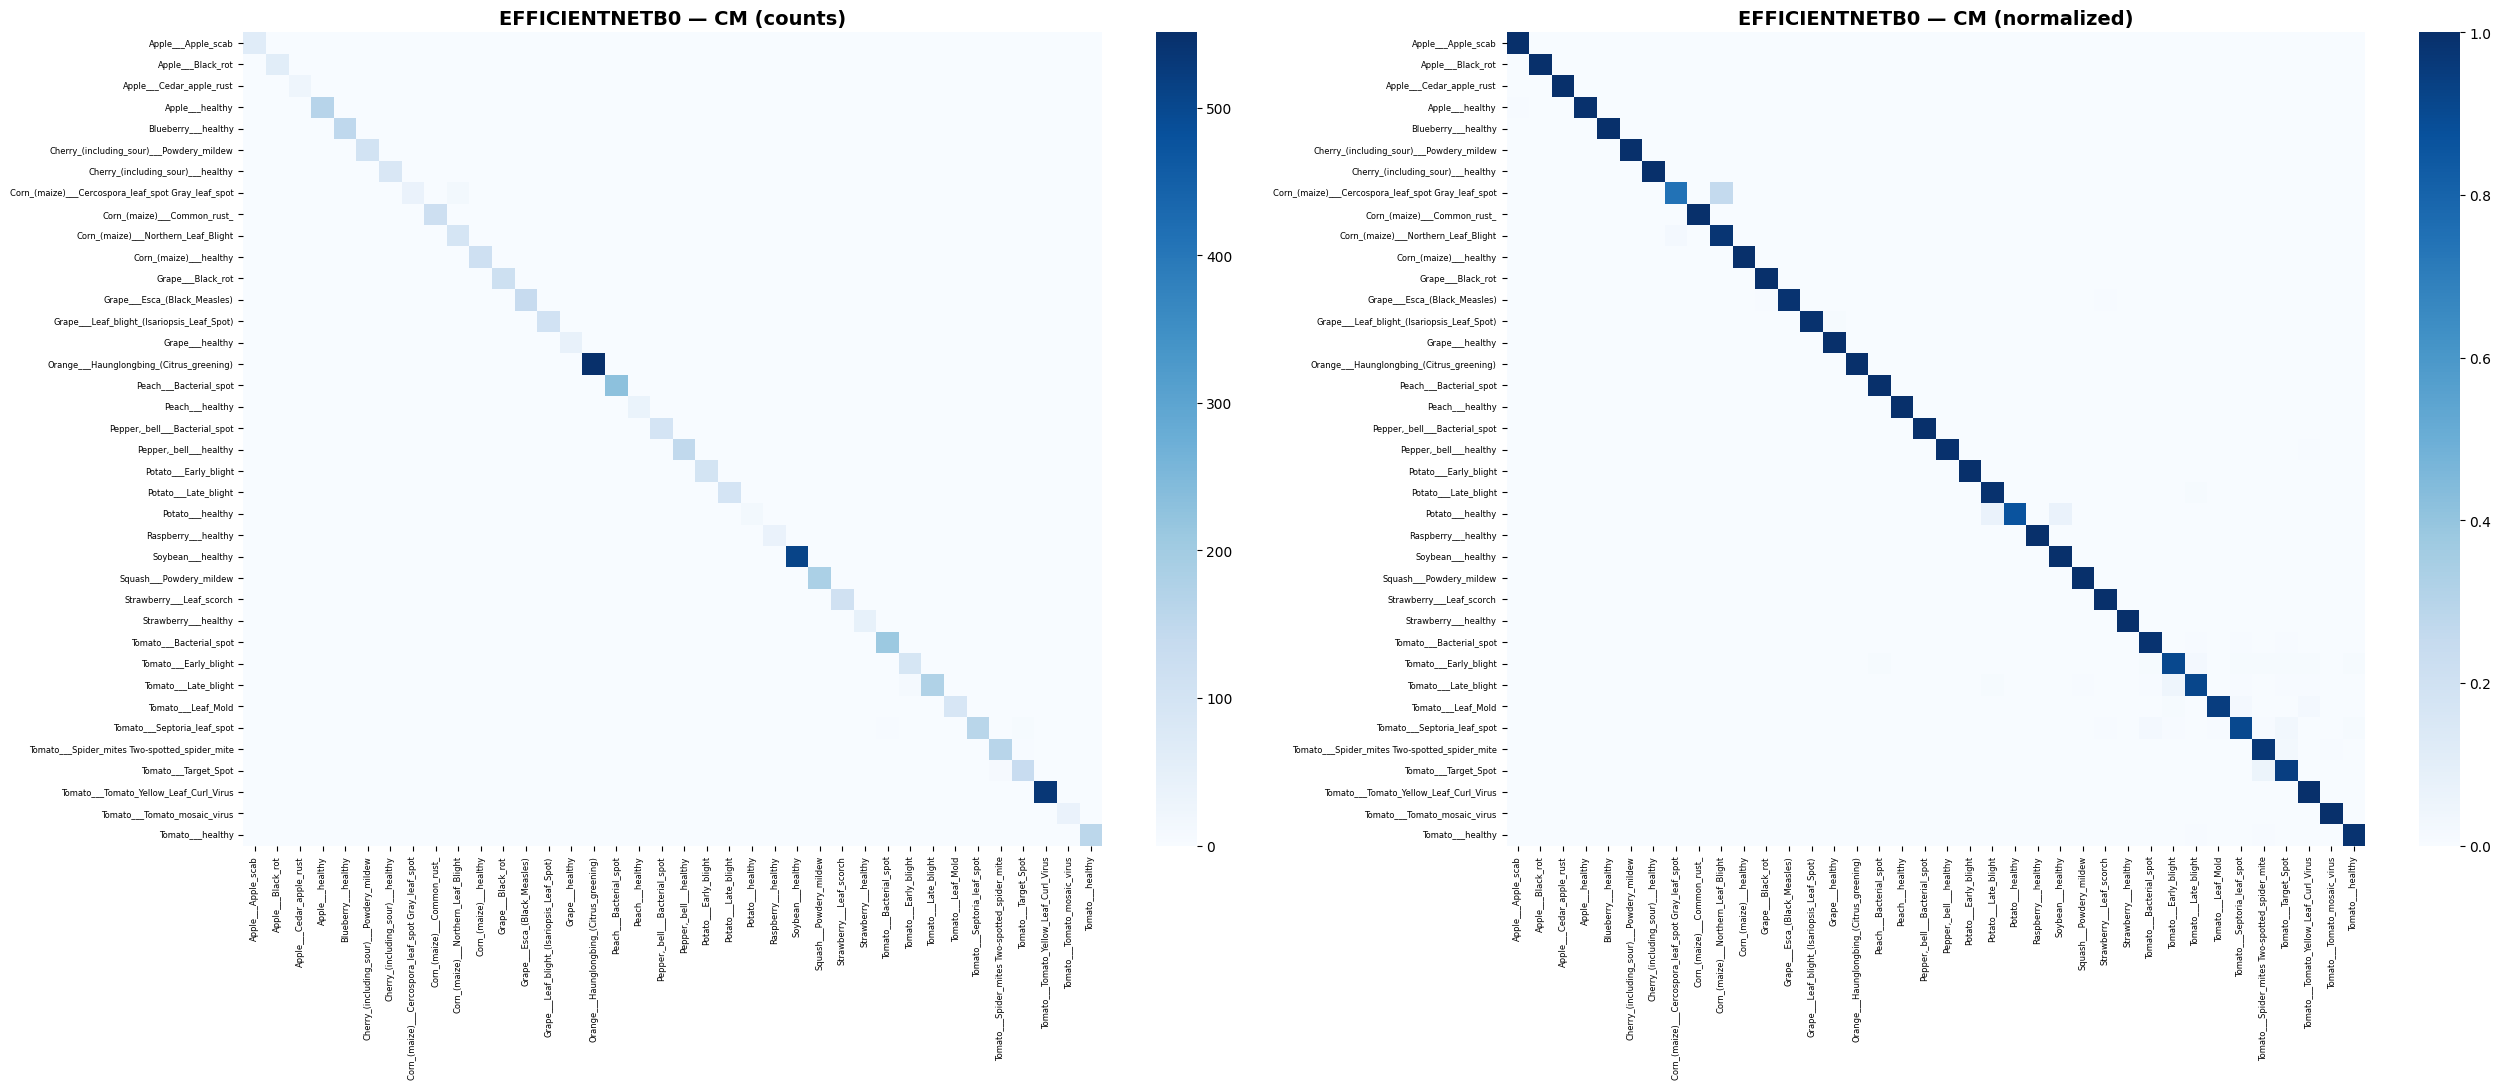


✅ EFFICIENTNETB0 COMPLETE!
   Model:   /content/drive/MyDrive/PlantDiseaseProject/results/models/efficientnetb0.keras
   Metrics: /content/drive/MyDrive/PlantDiseaseProject/results/metrics/efficientnetb0_metrics.json


In [4]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix


MODEL_NAME = 'efficientnetb0'


PROJECT_DRIVE = '/content/drive/MyDrive/PlantDiseaseProject'
MODELS_DIR  = os.path.join(PROJECT_DRIVE, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_DRIVE, 'results', 'metrics')
FIG_DIR     = os.path.join(PROJECT_DRIVE, 'results', 'figures')
for d in [MODELS_DIR, METRICS_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

# --- Build the transfer learning model ---
def build_transfer_model(model_name, num_classes):
    if model_name == 'resnet50':
        base = tf.keras.applications.ResNet50(
            weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
        # ResNet50 expects caffe-style preprocessing on [0, 255]
        preprocess = lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
    elif model_name == 'mobilenetv2':
        base = tf.keras.applications.MobileNetV2(
            weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
        # MobileNetV2 expects [-1, 1]
        preprocess = lambda x: (x * 2.0) - 1.0
    elif model_name == 'efficientnetb0':
        base = tf.keras.applications.EfficientNetB0(
            weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
        # EfficientNetB0 has internal rescaling
        preprocess = lambda x: x * 255.0
    else:
        raise ValueError(f"Unknown model: {model_name}")

    base.trainable = False   # Freeze backbone

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Lambda(preprocess, name='preprocess')(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name=model_name)

model = build_transfer_model(MODEL_NAME, NUM_CLASSES)
total_params     = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

print(f"\n📋 {MODEL_NAME.upper()}")
print(f"   Total params:     {total_params:,}")
print(f"   Trainable params: {trainable_params:,} (head only — backbone frozen)")

# --- Compile ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- Callbacks ---
ckpt_path = os.path.join(MODELS_DIR, f'{MODEL_NAME}.keras')
callbacks_list = [
    callbacks.ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=2, verbose=1, min_lr=1e-6),
]

# --- Train ---
print(f"\n🚀 Training {MODEL_NAME.upper()}...\n")
t0 = time.time()
history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=12, callbacks=callbacks_list,
)
train_time = time.time() - t0
print(f"\n⏱️ Training time: {train_time/60:.1f} min")

# --- Save history ---
hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
hist_dict['train_time_min'] = train_time / 60
hist_dict['total_params'] = int(total_params)
hist_dict['trainable_params'] = int(trainable_params)
with open(os.path.join(METRICS_DIR, f'{MODEL_NAME}_history.json'), 'w') as f:
    json.dump(hist_dict, f, indent=2)

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title(f'{MODEL_NAME.upper()} — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title(f'{MODEL_NAME.upper()} — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'{MODEL_NAME}_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Evaluate on test set ---
print(f"\n📊 Evaluating on test set...")
t0 = time.time()
y_pred_probs = model.predict(test_ds, verbose=1)
inference_time = time.time() - t0
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds])

test_acc = (y_pred == y_true).mean()
report = classification_report(y_true, y_pred, target_names=class_names,
                                output_dict=True, zero_division=0)

print(f"\n🎯 TEST Accuracy: {test_acc*100:.2f}%")
print(f"🎯 Macro F1:      {report['macro avg']['f1-score']:.4f}")
print(f"⏱️ Inference:     {inference_time/len(y_true)*1000:.2f} ms/image")

# --- Save metrics ---
metrics = {
    'model_name': MODEL_NAME,
    'test_accuracy': float(test_acc),
    'macro_f1': float(report['macro avg']['f1-score']),
    'weighted_f1': float(report['weighted avg']['f1-score']),
    'macro_precision': float(report['macro avg']['precision']),
    'macro_recall': float(report['macro avg']['recall']),
    'total_params': int(total_params),
    'trainable_params': int(trainable_params),
    'train_time_min': float(train_time/60),
    'inference_ms_per_image': float(inference_time/len(y_true)*1000),
    'test_samples': int(len(y_true)),
    'per_class': {cls: {
        'precision': float(report[cls]['precision']),
        'recall':    float(report[cls]['recall']),
        'f1':        float(report[cls]['f1-score']),
        'support':   int(report[cls]['support']),
    } for cls in class_names}
}
with open(os.path.join(METRICS_DIR, f'{MODEL_NAME}_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(26, 11))
sns.heatmap(cm, ax=axes[0], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'{MODEL_NAME.upper()} — CM (counts)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=6)
plt.setp(axes[0].get_xticklabels(), rotation=90)
sns.heatmap(cm_norm, ax=axes[1], cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'{MODEL_NAME.upper()} — CM (normalized)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=6)
plt.setp(axes[1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f'{MODEL_NAME}_confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ {MODEL_NAME.upper()} COMPLETE!")
print(f"   Model:   {ckpt_path}")
print(f"   Metrics: {METRICS_DIR}/{MODEL_NAME}_metrics.json")